# Практическое занятие №6: Полный цикл разведочного анализа данных (EDA) на реальном датасете

## Цель:
Применить на практике полный цикл разведочного анализа данных (EDA) к реальному набору данных. Научиться формулировать гипотезы, проверять их 
с помощью визуализации и статистических методов, а также представлять 
результаты анализа в структурированном виде.

### Выполнил: Мамаев А.
### Вариант 4: Iris (цветки ириса)

## Шаг 1. Загрузка и первичный анализ (Discover)

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Загружаем данные 
df = sns.load_dataset('iris') 
print("Размер исходных данных:", df.shape) 
print("\nПервые 5 строк:") 
df.head()

Размер исходных данных: (150, 5)

Первые 5 строк:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


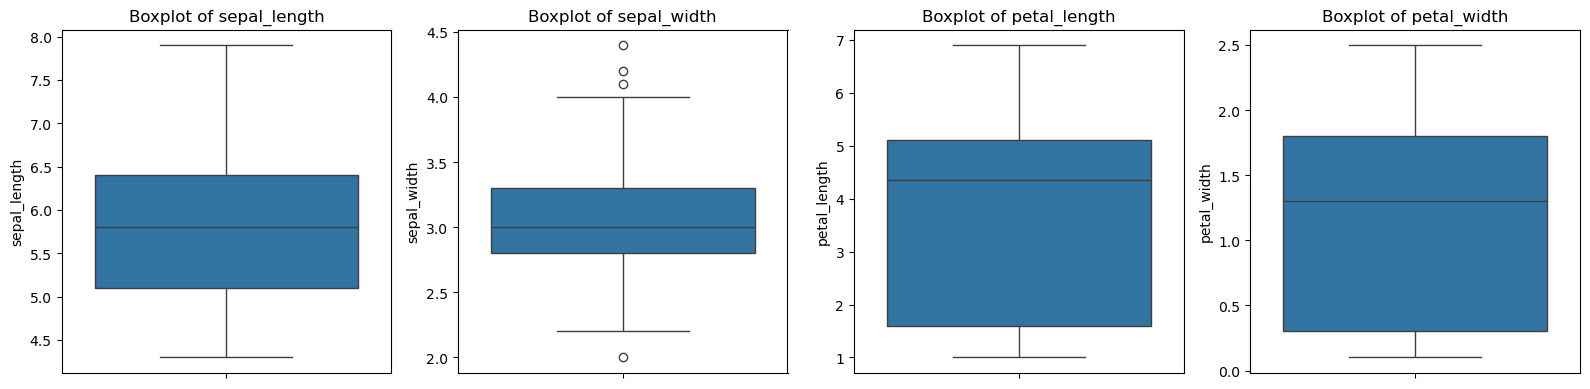

In [7]:
# Визуализация выбросов с помощью boxplot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Краткий вывод по шагу 1 - Discover
1. **Пропуски:**
   - Во всех столбцах количество пропусков = 0.
2. **Дубликаты:**
   - Дубликатов строк: 0.
3. **Выбросы:**
   - На boxplot аномальных точек не обнаружено.
   - По статистике `.describe() нет отрицательных значений или нулей в длинах.
4. **Типы данных:**
   - 4 числовых столбца (float64)
   - 1 категориальный (species) — object

## Шаг 2. Структурирование данных (Structure) 

In [12]:
print("Текущие названия столбцов:")
print(df.columns.tolist())

Текущие названия столбцов:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [21]:
# Переименуем столбцы
df_renamed = df.rename(columns={
    'sepal_length': 'sepal_length_cm',
    'sepal_width': 'sepal_width_cm',
    'petal_length': 'petal_length_cm',
    'petal_width': 'petal_width_cm',
    'species': 'species_name'
})

print("Новые названия столбцов (добавлены единицы измерения):")
print(df_renamed.columns.tolist())

Новые названия столбцов (добавлены единицы измерения):
['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'species_name']


### Краткий вывод по шагу 2 - Structure

**1. Переименование столбцов (.rename()):**
   - Исходные имена: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`, `species`
   - Для информативности добавлены единицы измерения (`_cm`).
   - Новые имена: `sepal_length_cm`, `sepal_width_cm`, `petal_length_cm`, `petal_width_cm`, `species_name`

**Общий вывод по этапу Structure:**
Структура данных в целом уже была оптимальна. Типы данных корректны. Скорректированы имена столбцов.

## Шаг 3. Очистка данных (Clean)

Заданный датасет уже достаточно "чистый", в нем отсуствуют дупликаты и пропущенные значения, поэтому операции по удалению дупликатов и чистке пропущенных значений пропускаем

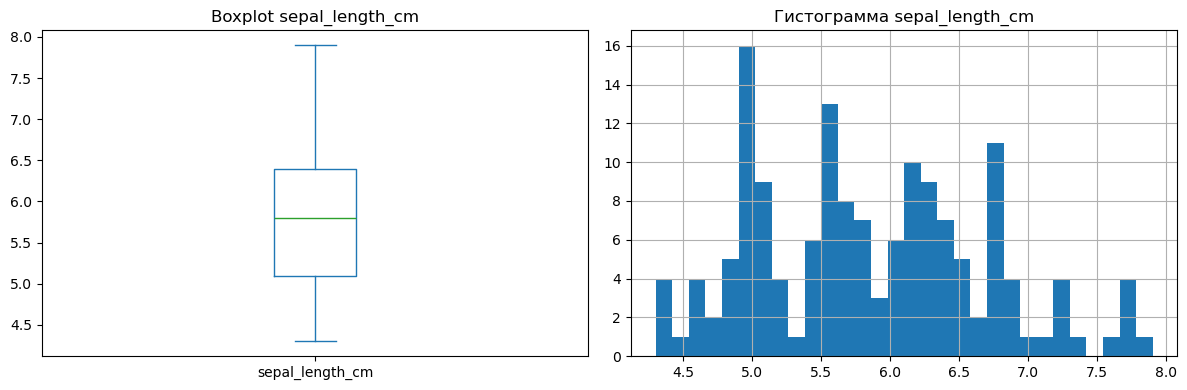

sepal_length_cm: Q1=5.10, Q3=6.40, IQR=1.30
Границы: нижняя=3.15, верхняя=8.35
Количество выбросов: 0
Вывод: выбросов нет


In [23]:
# Визуализация для sepal_length_cm
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_renamed['sepal_length_cm'].plot(kind='box')
plt.title('Boxplot sepal_length_cm')

plt.subplot(1, 2, 2)
df_renamed['sepal_length_cm'].hist(bins=30)
plt.title('Гистограмма sepal_length_cm')

plt.tight_layout()
plt.show()

# Обнаружение выбросов методом IQR
Q1 = df_renamed['sepal_length_cm'].quantile(0.25)
Q3 = df_renamed['sepal_length_cm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_renamed[(df_renamed['sepal_length_cm'] < lower) | (df_renamed['sepal_length_cm'] > upper)]

print(f"sepal_length_cm: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Границы: нижняя={lower:.2f}, верхняя={upper:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Вывод: выбросов нет")

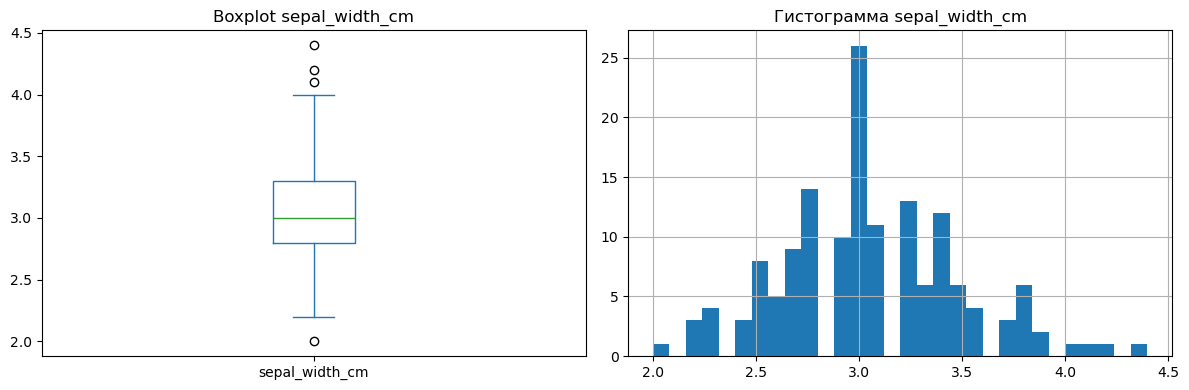

sepal_width_cm: Q1=2.80, Q3=3.30, IQR=0.50
Границы: нижняя=2.05, верхняя=4.05
Количество выбросов: 4
Значения-выбросы: [4.4, 4.1, 4.2, 2.0]
Вывод: есть выбросы


In [25]:
# Визуализация для sepal_width_cm
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_renamed['sepal_width_cm'].plot(kind='box')
plt.title('Boxplot sepal_width_cm')

plt.subplot(1, 2, 2)
df_renamed['sepal_width_cm'].hist(bins=30)
plt.title('Гистограмма sepal_width_cm')

plt.tight_layout()
plt.show()

# Обнаружение выбросов методом IQR
Q1 = df_renamed['sepal_width_cm'].quantile(0.25)
Q3 = df_renamed['sepal_width_cm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_renamed[(df_renamed['sepal_width_cm'] < lower) | (df_renamed['sepal_width_cm'] > upper)]

print(f"sepal_width_cm: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Границы: нижняя={lower:.2f}, верхняя={upper:.2f}")
print(f"Количество выбросов: {len(outliers)}")

print(f"Значения-выбросы: {outliers['sepal_width_cm'].tolist()}")
print(f"Вывод: есть выбросы")


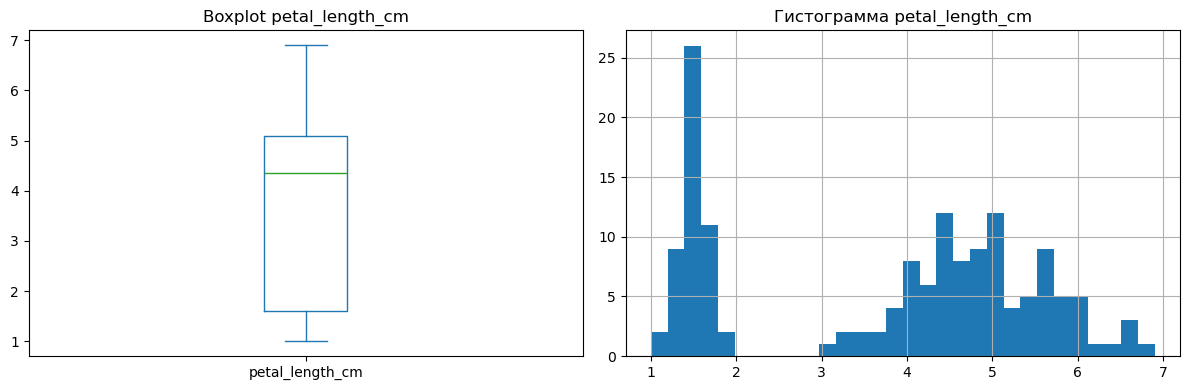

petal_length_cm: Q1=1.60, Q3=5.10, IQR=3.50
Границы: нижняя=-3.65, верхняя=10.35
Количество выбросов: 0
Вывод: выбросов нет


In [26]:
# Визуализация для petal_length_cm
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_renamed['petal_length_cm'].plot(kind='box')
plt.title('Boxplot petal_length_cm')

plt.subplot(1, 2, 2)
df_renamed['petal_length_cm'].hist(bins=30)
plt.title('Гистограмма petal_length_cm')

plt.tight_layout()
plt.show()

# Обнаружение выбросов методом IQR
Q1 = df_renamed['petal_length_cm'].quantile(0.25)
Q3 = df_renamed['petal_length_cm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_renamed[(df_renamed['petal_length_cm'] < lower) | (df_renamed['petal_length_cm'] > upper)]

print(f"petal_length_cm: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Границы: нижняя={lower:.2f}, верхняя={upper:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Вывод: выбросов нет")

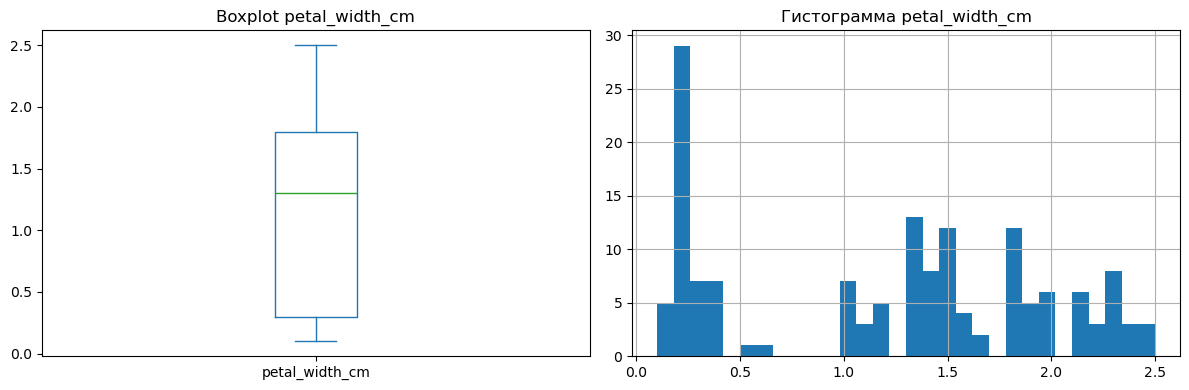

petal_width_cm: Q1=0.30, Q3=1.80, IQR=1.50
Границы: нижняя=-1.95, верхняя=4.05
Количество выбросов: 0
Вывод: выбросов нет


In [27]:
# Визуализация для petal_width_cm
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_renamed['petal_width_cm'].plot(kind='box')
plt.title('Boxplot petal_width_cm')

plt.subplot(1, 2, 2)
df_renamed['petal_width_cm'].hist(bins=30)
plt.title('Гистограмма petal_width_cm')

plt.tight_layout()
plt.show()

# Обнаружение выбросов методом IQR
Q1 = df_renamed['petal_width_cm'].quantile(0.25)
Q3 = df_renamed['petal_width_cm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df_renamed[(df_renamed['petal_width_cm'] < lower) | (df_renamed['petal_width_cm'] > upper)]

print(f"petal_width_cm: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Границы: нижняя={lower:.2f}, верхняя={upper:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Вывод: выбросов нет")

## Краткий вывод по шагу 3 - Clean

**Результаты проверки методом IQR:**

1. **sepal_length_cm** - выбросов нет
2. **sepal_width_cm** - обнаружено 4 выброса (значения 4.4, 4.1, 4.2, 2.0)
3. **petal_length_cm** - выбросов нет  
4. **petal_width_cm** - выбросов нет

**Решение:** Выбросы оставляем, так как действительно могут быть такие размеры.

## Шаг 4. Обогащение данных (Enrich)

In [32]:
# Создаём признак petal_area = petal_length × petal_width
df_renamed['petal_area'] = df_renamed.apply(lambda row: row['petal_length_cm'] * row['petal_width_cm'], axis=1)

print(df_renamed[['petal_length_cm', 'petal_width_cm', 'petal_area']].head())

   petal_length_cm  petal_width_cm  petal_area
0              1.4             0.2        0.28
1              1.4             0.2        0.28
2              1.3             0.2        0.26
3              1.5             0.2        0.30
4              1.4             0.2        0.28


In [33]:
# Создаём признак sepal_area = sepal_length × sepal_width
df_renamed['sepal_area'] = df_renamed['sepal_length_cm'] * df_renamed['sepal_width_cm']

print(df_renamed[['sepal_length_cm', 'sepal_width_cm', 'sepal_area']].head())

   sepal_length_cm  sepal_width_cm  sepal_area
0              5.1             3.5       17.85
1              4.9             3.0       14.70
2              4.7             3.2       15.04
3              4.6             3.1       14.26
4              5.0             3.6       18.00


In [34]:
# Создаём признак shape_ratio = petal_length / sepal_length
df_renamed['shape_ratio'] = df_renamed.apply(lambda row: row['petal_length_cm'] / row['sepal_length_cm'], axis=1)

print(df_renamed[['petal_length_cm', 'sepal_length_cm', 'shape_ratio']].head())

   petal_length_cm  sepal_length_cm  shape_ratio
0              1.4              5.1     0.274510
1              1.4              4.9     0.285714
2              1.3              4.7     0.276596
3              1.5              4.6     0.326087
4              1.4              5.0     0.280000


In [37]:
# Добавляем столбец со средним значением petal_length для каждого вида
df_renamed['avg_petal_length_by_species'] = df_renamed.groupby('species_name')['petal_length_cm'].transform('mean')

print(f"\nСредние значения по видам:")
print(df_renamed.groupby('species_name')['petal_length_cm'].mean().round(2))


Средние значения по видам:
species_name
setosa        1.46
versicolor    4.26
virginica     5.55
Name: petal_length_cm, dtype: float64


## Краткий вывод по шагу 4 - Enrich

### Созданные признаки:

1. **petal_area** - petal_length × petal_width
2. **sepal_area** - sepal_length × sepal_width  
3. **shape_ratio** - petal_length / sepal_length
4. **avg_petal_length_by_species**

## Шаг 5. Валидация (Validate)

In [40]:
print(f"Размер итогового датасета: {df_renamed.shape}")

Размер итогового датасета: (150, 9)


In [41]:
print(f"Пропуски в каждом столбце:\n{df_renamed.isnull().sum()}")  

Пропуски в каждом столбце:
sepal_length_cm                0
sepal_width_cm                 0
petal_length_cm                0
petal_width_cm                 0
species_name                   0
petal_area                     0
sepal_area                     0
shape_ratio                    0
avg_petal_length_by_species    0
dtype: int64


In [43]:
duplicates_count = df_renamed.duplicated().sum()
print(f"Количество дубликатов:\n{df_renamed.duplicated().sum()}")  

Количество дубликатов:
1


In [47]:
all_duplicates = df_renamed[df_renamed.duplicated(keep=False)]
print("Все строки с дубликатами:")
print(all_duplicates)

Все строки с дубликатами:
     sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
101              5.8             2.7              5.1             1.9   
142              5.8             2.7              5.1             1.9   

    species_name  petal_area  sepal_area  shape_ratio  \
101    virginica        9.69       15.66      0.87931   
142    virginica        9.69       15.66      0.87931   

     avg_petal_length_by_species  
101                        5.552  
142                        5.552  


Обнаружен один дубликат, очистим датасет от дубликатов

In [49]:
df_no_duplicates = df_renamed.drop_duplicates(keep='first')

print(f"Было строк: {len(df_renamed)}")
print(f"Стало строк: {len(df_no_duplicates)}")

Было строк: 150
Стало строк: 149


In [52]:
print("Типы всех столбцов:")
print(df_no_duplicates.dtypes)

Типы всех столбцов:
sepal_length_cm                float64
sepal_width_cm                 float64
petal_length_cm                float64
petal_width_cm                 float64
species_name                    object
petal_area                     float64
sepal_area                     float64
shape_ratio                    float64
avg_petal_length_by_species    float64
dtype: object


In [53]:
print("Статистика обновленного датасета:")
print(df_no_duplicates.describe())

Статистика обновленного датасета:
       sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
count       149.000000      149.000000       149.000000      149.000000   
mean          5.843624        3.059732         3.748993        1.194631   
std           0.830851        0.436342         1.767791        0.762622   
min           4.300000        2.000000         1.000000        0.100000   
25%           5.100000        2.800000         1.600000        0.300000   
50%           5.800000        3.000000         4.300000        1.300000   
75%           6.400000        3.300000         5.100000        1.800000   
max           7.900000        4.400000         6.900000        2.500000   

       petal_area  sepal_area  shape_ratio  avg_petal_length_by_species  
count  149.000000  149.000000   149.000000                   149.000000  
mean     5.767919   17.837383     0.616325                     3.745960  
std      4.717353    3.368472     0.240498                     1.712

In [54]:
# Сохраняем результат 
df_no_duplicates.to_csv('iris_cleaned.csv', index=False) 
print("Датасет сохранён в файл iris_cleaned.csv")

Датасет сохранён в файл iris_cleaned.csv
